# **Maestría en Inteligencia Artificial Aplicada**

## Curso: **Procesamiento de Lenguaje Natural**

### Tecnológico de Monterrey

### Prof Luis Eduardo Falcón Morales

### **Actividad en Equipo - Semanas 4 y 5**

### **Vectores Embebidos de HuggingFace**

#### **Nombres y matrículas de los integrantes del equipo:**

* Leonardo Daniel Rodriguez Vega - A01797465
* Cinthia Abigail Sánchez Silva - A01281280
* Rafael Fernando Olmedo Aguilar - A01796862
* Julio Ricardo Velázquez Hernández - A01796953

In [39]:
# Aquí deberán incluir todas las librerías que requieran durante esta actividad:

import pandas as pd
import numpy as np
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split



En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI llamados **amazon_cells_labelled.txt**, **imdb_labelled.txt** y   **yelp_labelled.txt**. Cada uno de estos archivos corresponden a comentarios de usuarios que adquirieron un celular a través de la plataforma de Amazon, de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMDb y sobre servicios de comida dejados en la plataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI cuya liga es la siguiente:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



# **Pregunta - 1:**



Descarga los 3 archivos de la plataforma de la UCI indicado previamente y genera un nuevo DataFrame de Pandas con ellos.

**Llama simplemente "df" a dicho DataFrame.**




In [40]:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


dfa = pd.read_csv('data/amazon_cells_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfi = pd.read_csv('data/imdb_labelled.txt', delimiter='\t', names=['review','label'], header=None, encoding='utf-8')
dfy = pd.read_csv('data/yelp_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')


#definimos nuestro codigo para limpiar los registros

newdfi=[]
for item  in dfi.values.tolist():
    #concatenamos la calificacion de nuestra cadena original
    cadena=(item[0])+'\t'+str(item[1])     
    oraciones=re.findall(r'.+\t[0-9]',cadena)
    if len(oraciones) > 0:
        for oracion in oraciones:
            scores=re.findall(r'(.+)\t([0-9])$',oracion)
            if scores:
                #realizamos la conversión de los scores para que sean enteros nuúmericos
                review=[(scores[0][0],int(scores[0][1]))]
                #newdfi+=scores
                newdfi+=review

    if len(oraciones)>1:
        print(f'comentarios corregidos en la oracion: {len(oraciones)}')
print('-'*100)


dfii = pd.DataFrame(newdfi, columns=['review','label'])

df = pd.concat([dfa, dfii, dfy], ignore_index=True)  

# *********** Aquí termina la sección de agregar código *************


comentarios corregidos en la oracion: 62
comentarios corregidos en la oracion: 16
comentarios corregidos en la oracion: 98
comentarios corregidos en la oracion: 26
comentarios corregidos en la oracion: 55
----------------------------------------------------------------------------------------------------


In [41]:
# Verifiquemos la información del DataFrame:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  3000 non-null   str  
 1   label   3000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 47.0 KB


In [42]:
# Y mostremos sus primeros registros:

df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


# **Pregunta - 2:**

Proceso de limpieza. Aplica el proceso de limpieza que consideres adecuado.











In [43]:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********
X = df.review     # Serie de strings
y = df.label      # Serie de enteros 0s y 1s


In [44]:
#definimos nuestros stopwords
nltk.download('punkt')    # es un tokenizador que ayuda a dividr el texto en enunciados mediante un modelo no-supervisado.
nltk.download('stopwords')    # para tener acceso a "stopwords" en varios idiomas.

mystopwords = stopwords.words('english') 


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/leodan1991/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/leodan1991/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [45]:
def clean_tok(doc):
  tokens=[]

  #convertimos la cadena a minusculas para optimizar las expresiones regulares
  palabras = re.findall(r'[a-z]{2,}',doc.lower())
  tokens_comentario=[]

  for palabra in palabras:
    es_stopword=False
    for sw in mystopwords:
      if palabra == sw:
        es_stopword=True
        break
    if not es_stopword:
      tokens.append(palabra)


  return tokens



In [46]:
#limpiamos los tokens
Xcleantok = [clean_tok(x) for x in X]


In [47]:
nltk.download('wordnet')

def clean_doc(doc):
  tokens=[]
  wnl = WordNetLemmatizer() 

  #Limpieza 1: aplicamos lematización a nuestros tokens
  palabras=[wnl.lemmatize(w,pos='v') for w in doc]
  #Limpieza 2: descartamos las palabras que hayan quedado con una dimensión a 1 para evitar confundirlas con alguna stopword
  tokens=[palabra for palabra in palabras if len(palabra)>1]
  

  return tokens


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/leodan1991/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [48]:
Xclean = [clean_doc(x) for x in Xcleantok]
# *********** Aquí termina la sección de agregar código *************

In [49]:
# Despleguemos los primeros comentarios después de tu proceso de limpieza:

for x in Xclean[0:5]:
  print(x)


['way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tie', 'charger', 'conversations', 'last', 'minutes', 'major', 'problems']
['mic', 'great']


# **Pregunta - 3:**



Realicemos una partición aleatoria con los porcentajes que consideres más adecuados. Utiliza una semilla para su reproducibilidad.

In [50]:

# ************* Inicia la sección de agregar código:*****************************


Xtrain, x_val_and_test, ytrain, y_val_and_test = train_test_split(Xclean, y, train_size=.70, shuffle=True, random_state=1)
Xval, Xtest, yval, ytest = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=1)



# *********** Termina la sección de agregar código *************


# verificemos las dimensiones obtenidas:
print('X,y Train:', len(Xtrain), len(ytrain))
print('X,y Val:', len(Xval), len(yval))
print('X,y Test', len(Xtest), len(ytest))

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


# **Pregunta - 4:**




### **Construye tu vocabulario a continuación utilizando solamente el conjunto de Train:**


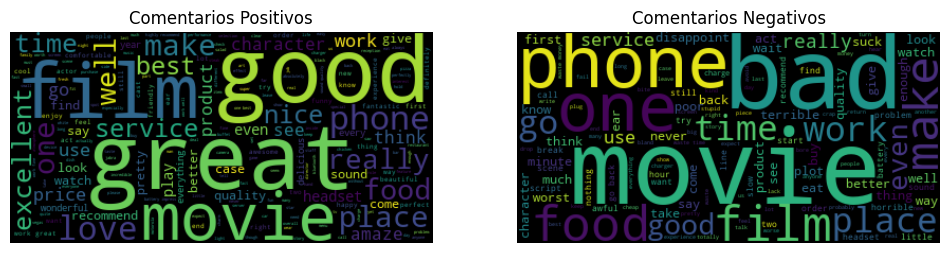

In [51]:
pos_tok=[]  # inicializamos listas de los tokens positivos y negativos
neg_tok=[] 


for x,c in zip(Xclean, y):   
  if c==1:
    pos_tok.extend(x)   # tokens usados en comentarios positivos
  else: 
    neg_tok.extend(x)   # tokens usados en comentarios negativos

pt = ' '.join(pos_tok)   # requerimos un solo string por cada clase para la nube de palabras.
nt = ' '.join(neg_tok)

##############################################################################

from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,12))

# Nube de palabras de comentarios positivos:
wordcloudnn = WordCloud().generate(pt)
ax1.imshow(wordcloudnn, interpolation='bilinear')
ax1.axis("off")
ax1.set_title('Comentarios Positivos')

# Nube de palabras de comentarios negativos:
wordcloudnn = WordCloud().generate(nt)
ax2.imshow(wordcloudnn, interpolation='bilinear')
ax2.axis("off")
ax2.set_title('Comentarios Negativos')

plt.show()


##############################################################################

In [ ]:
# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

from collections import Counter

midiccionario = Counter()

for k in range(len(Xtrain)):
  midiccionario.update(Xtrain[k])


print('Longitud del diccionario:', len(midiccionario))
print('\n(word,frequency):')
print(midiccionario.most_common(10))


Longitud del diccionario: 3396

(word,frequency):
[('good', 164), ('great', 138), ('phone', 134), ('film', 130), ('movie', 119), ('work', 113), ('like', 101), ('time', 101), ('one', 97), ('go', 89)]


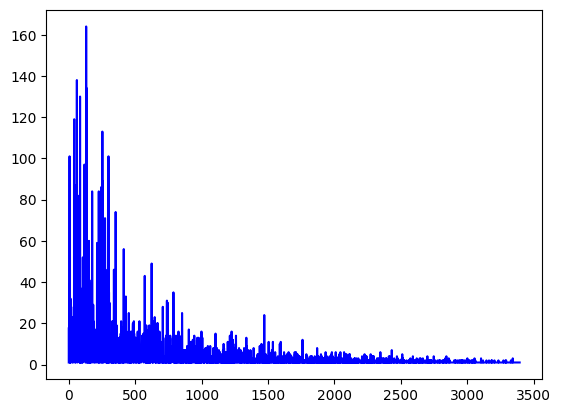

In [53]:

plt.plot(list(np.arange(len(midiccionario))), list(midiccionario.values()), color='blue')
plt.show()


In [ ]:
min_freq = 10

midicc = Counter()

for k in midiccionario:
    if midiccionario[k]>=min_freq:
        midicc[k]=midiccionario[k]
        


In [55]:
# a.	Usa el conjunto de entrenamiento para generar tu vocabulario con un tamaño que consideres adecuado:

print('Nueva longitud del nuevo vocabulario:', len(midicc))
print(list(midicc.items())[0:5])     # veamos algunos elementos del diccionario.

Nueva longitud del nuevo vocabulario: 258
[('star', 18), ('much', 39), ('better', 38), ('people', 23), ('like', 101)]


In [56]:
# b.	Indica el tamaño del vocabulario generado.

print('Longitud del vocabulario generado:')


# ******* Inicia la sección de agregar código: ***********


print(len(midicc))



# *********** Aquí termina la sección de agregar código *************

Longitud del vocabulario generado:
258


In [57]:
# c.	Con el vocabulario generado, filtra los conjuntos de entrenamiento,
#     validación y prueba para que todos los comentarios usen solamente las
#     palabras de este vocabulario.

#     Llamar train_X, val_X y test_X a estos tres conjuntos.


# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

train_X = []
for ss in Xtrain:
  train_X.append([w for w in ss if w in midicc])

val_X = []
for ss in Xval:
  val_X.append([w for w in ss if w in midicc])

test_X = []
for ss in Xtest:
  test_X.append([w for w in ss if w in midicc])


# *********** Aquí termina la sección de agregar código *************


In [58]:
# Vemos el resultado de los primeros comentarios del conjunto de validación:

for ss in val_X[0:5]:
  print(ss)

['use', 'never', 'tell', 'go', 'next']
['food', 'way', 'small']
['good', 'price']
['place', 'two', 'way']
['night']


# **Pregunta - 5:**

Incluye tus comentarios sobre cada modelo de HuggingFace indicado.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

* **a) bge-base-en-v1.5**

El modelo BGE se basa en la arquitectura de BERT; es un encoder que entrena representaciones bidireccionales a partir de texto sin etiquetar. Este modelo permite visualizar el contexto de las palabras tanto de izquierda como de derecha, permitiendo obtener la representación numérica con base en el contexto de las palabras que lo acontecen como las que siguen, dando un mayor valor al embedding.

Los principales paradigmas de este modelo son los siguientes:


1. **Preentrenamiento (pre-training):** El modelo aplica máscaras para el entrenamiento bidireccional, con el objetivo de evitar que el modelo vea las palabras que se están analizando, evitando un mal entrenamiento y, por ende, un mal rendimiento del modelo. Para ello, el modelo implementa las siguientes tareas principales:


* Masked Language Model (MLM) [MASK]: El modelo selecciona el 15% de las palabras de manera aleatoria, con las que las reemplaza con el token [MASK], con la finalidad de tratar de encontrar cuáles son las palabras ocultas y mejorar el rendimiento del modelo.


* Next Sentence Prediction (NSP): Para esta tarea, el modelo presenta pares de oraciones A y B, con los cuales en un 50% de las veces B es la frase que sigue de la oración A, y el otro 50% es una oración diferente del corpus; para ello, el modelo trata de predecir si B es la oración que sigue de A.


2. **Ajuste fino (fine-tuning):** El ajuste fino es un proceso para realizar optimizaciones sobre la información aprendida en el preentrenamiento, con la finalidad de ajustar el modelo para resolver una tarea en específico. A continuación se explican los pasos para el ajuste fino:


* Se inicializan los pesos sinápticos con los valores obtenidos en el preentrenamiento.
* Se agrega capa de salida; se evitan las que se usaban en el preentrenamiento, como las que ocultan las palabras.
* Se entrena el modelo con datos específicos y etiquetados.
* Se realiza backpropagation para actualizar los valores y mejorar el rendimiento del modelo.


A continuación se muestra la arquitectura de BERT:

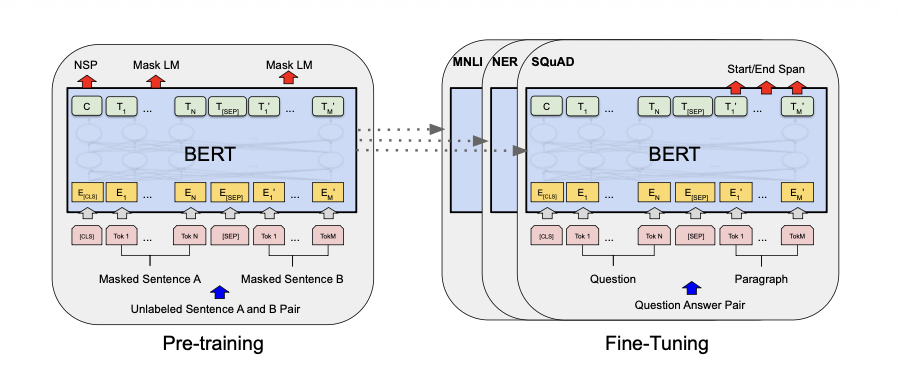


El modelo bge-base-en-v1.5 como se explicó previamente se basa en BERT, al cual se realizaron algunos ajustes los cuales se destacan los siguientes:

* Búsqueda de similitudes: el modelo busca textos semanticamente identicos o complementarios (en una relación pregunta-respuesta), con la finalidad de descartar textos irrelevantes.

* Pooling: BGE extrae los estados ocultos de la última capa y aplica CLS pooling o Mean pooling (promediar el peso de los tokens), optimizado fuertemente durante su sintonización fina.

* Normalización: Se configuró el modelo para que los vectores de salida estén normalizados. Esto permite que calcular la similitud semántica sea increíblemente rápido utilizando simplemente un producto punto (Dot Product)


* **b) bge-large-en-v1.5**

Este modelo, al igual que bge-base-en-v1.5, se basa en BERT y posee las mismas configuraciones; su única variante son las dimensiones con las que se construye la arquitectura del modelo. A continuación, una tabla comparativa de los modelos. 

| Característica | bge-base-en-v1.5 | bge-large-en-v1.5 |
| :--- | :---: | :---: |
| **Modelo Base** | BERT-base | BERT-large |
| **Número de Parámetros** | 110 Millones aprox. | 335 Millones aprox. |
| **Dimensiones del Embedding** |768 | 1024 |
| **Límite de Tokens (Contexto)** | 512 tokens | 512 tokens |


* **c)	e5-base-v2**

Este modelo, su base arquitectónica es BERT (explicada previamente); sin embargo, tiene sus configuraciones en específico, lo cual lo hace un modelo diferente. A continuación, los cambios más relevantes:

1. Prefijos: El modelo requiere el uso de prefijos para los diferentes tipos de tareas para las que se requiere el modelo:

* query: Este prefijo indica que se está llevando a cabo una consulta.

* passage: Este prefijo indica que se está tratando de un documento que requiere ser procesado.


2. Los embeddings resultantes ya se encuentran normalizados, por lo que no requieren un proceso extra para hacer uso de ellos.

3. Parámetros: El modelo fue entrenado con 110 millones de parámetros aproximadamente, lo cual le permite ser muy ligero.

Un punto relevante de este modelo es el uso de los prefijos, debido a que, si no se implementan o se realiza una implementación errónea, baja muy drásticamente el rendimiento del mismo.



### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Pregunta - 6:**

In [59]:
# a) Cargar el modelo de embeddings de HuggingFace seleccionado:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('BAAI/bge-base-en-v1.5')


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9219.47it/s]


In [ ]:

embeddings = model.encode(list(midicc), normalize_embeddings=True)


# *********** Aquí termina la sección de agregar código *************

In [61]:
embeddings.shape

(258, 768)

In [ ]:
# b) Primeros 3 elementos clave:valor del diccionario generado.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

vocabulario_dict = {
    palabra: embedding.tolist()
    for palabra, embedding in zip(list(midicc), embeddings)
}


for i in range(3):
    print(list(vocabulario_dict.items())[i]) 

# *********** Aquí termina la sección de agregar código *************



('star', [-0.06173289194703102, 0.028511881828308105, 0.06004057452082634, -0.020238924771547318, 0.015886390581727028, 0.030028872191905975, 0.060631077736616135, -0.0045888409949839115, -0.04229496791958809, -0.029245438054203987, -0.045525673776865005, -0.014339436776936054, -0.07665038108825684, 0.005361971911042929, -0.004987496882677078, 0.04388217628002167, 0.04702211916446686, 0.05277591198682785, -0.025546051561832428, -0.01811676099896431, 0.005320476833730936, 0.06832429766654968, 0.032343242317438126, 0.017403502017259598, -0.016920290887355804, -0.04371967166662216, 0.007891323417425156, 0.02533142641186714, -0.023255830630660057, -0.02114856243133545, 0.008598405867815018, 0.01933836191892624, -0.01823825016617775, -0.021263420581817627, -0.0015700403600931168, -0.016529496759176254, 0.02947462536394596, 0.010440713725984097, -0.039405595511198044, -0.027280660346150398, 0.0015912795206531882, -0.035382773727178574, 0.025269759818911552, -0.017968490719795227, -0.01412178

In [63]:
# c) Tamaño del diccionario generado:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


print(f'Tamaño del diccionario {len(vocabulario_dict)}')

# *********** Aquí termina la sección de agregar código *************


Tamaño del diccionario 258


# **Pregunta - 7:**




Generamos los vectores embebidos a partir de los conjuntos de entrenamiento, validación y prueba y con las características indicadas en el archivo PDF.

Los llamaremos trainEmb, valEmb y testEmb, respectivamente.


In [ ]:

def genera_emb(conjuntoX, mivocab):

    #generamos los embedings promediados de nuestros comentarios
    comen_embeding=[]
    for comentario in conjuntoX:
        vec_comentario=np.zeros(768)
        tot_palabras_commentario=len(comentario)
        #tener cuidado con las cantidades cero (surgieron por el proceso de limpieza)
        if tot_palabras_commentario==0: 
            tot_palabras_commentario=1
            #print(comentario)
        for p in comentario:
            for palabra in mivocab:
                if palabra == p:
                    #sumamos los vectores
                    vec_comentario=vec_comentario+np.array(mivocab[palabra])
        
        #obtenemos el promedio de los embedings
        vec_comentario=[item/tot_palabras_commentario for item in vec_comentario]
        comen_embeding.append(vec_comentario)

    return comen_embeding


In [65]:
# a) Comentarios con vectores embebidos.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

#generamos los embedings promediados de nuestros comentarios
#trainEmb, valEmb y testEmb
trainEmb=genera_emb(Xtrain,vocabulario_dict)
valEmb=genera_emb(Xval,vocabulario_dict)
testEmb=genera_emb(Xtest,vocabulario_dict)

# *********** Aquí termina la sección de agregar código *************

In [66]:
# b) Dimensiones de los conjuntos trainEmb, valEmb y testEmb.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


print(f'Tamaño de conjunto de entrenamiento {len(trainEmb)}')
print(f'Tamaño de conjunto de validación {len(valEmb)}')
print(f'Tamaño de conjunto de prueba {len(testEmb)}')


# *********** Aquí termina la sección de agregar código *************

Tamaño de conjunto de entrenamiento 2100
Tamaño de conjunto de validación 450
Tamaño de conjunto de prueba 450


# **Pregunta - 8:**

In [67]:
tokenizer = model.tokenizer

def contar_tokens(textos):
    total_tokens = 0
    comentarios=[]
    for texto in textos:
        #se concatenan los tokens, debido a que la función tokenizer requiere una cadena de texto
        str_comen = ' '.join(texto)
        comentarios.append(str_comen)
        
    tokens = tokenizer(comentarios, padding=False, truncation=False)
    # Sumamos la longitud de las listas de tokens de cada comentario
    total_tokens = sum(len(ids) for ids in tokens['input_ids'])
    return total_tokens

In [68]:

# Número de tokens generedos al obtener cada uno de los conjuntos trainEmb, valEmb y testEmb.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

print(f"Tokens en Train: {contar_tokens(Xtrain)}")
print(f"Tokens en Val:   {contar_tokens(Xval)}")
print(f"Tokens en Test:  {contar_tokens(Xtest)}")


# *********** Aquí termina la sección de agregar código *************

Tokens en Train: 18492
Tokens en Val:   4015
Tokens en Test:  3985


# **Pregunta - 9:**



Entrenamiento y reporte de los modelos de Regresión Logística y Bosque Aleatorio (Random Forest).


In [69]:
# 9a) REGRESIÓN LOGÍSTICA:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

modeloLRcount =  LogisticRegression(
    max_iter=300, 
    C=0.006,
    random_state=1
)
modeloLRcount.fit(trainEmb, ytrain)
predLR = modeloLRcount.predict(trainEmb)


print(classification_report(ytrain, predLR))
print('LR: Train-accuracy: %.2f%%' % (100*modeloLRcount.score(trainEmb, ytrain)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRcount.score(valEmb, yval)))


# *********** Aquí termina la sección de agregar código *************


              precision    recall  f1-score   support

           0       0.55      0.99      0.70      1068
           1       0.94      0.15      0.25      1032

    accuracy                           0.58      2100
   macro avg       0.74      0.57      0.48      2100
weighted avg       0.74      0.58      0.48      2100

LR: Train-accuracy: 57.52%
LR: Val-accuracy: 54%


In [70]:
# 9b) BOSQUE ALEATORIO (Random Forest):

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


modeloRFcount = RandomForestClassifier(
    criterion='log_loss',
    n_estimators=400,
    max_depth=4,
    random_state=1,
    max_features='sqrt',
    min_samples_split=10,
    min_samples_leaf=2
    
)
modeloRFcount.fit(trainEmb, ytrain)
predRF = modeloRFcount.predict(trainEmb)
print(classification_report(ytrain, predLR))


print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFcount.score(trainEmb, ytrain)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFcount.score(valEmb, yval)))

# *********** Aquí termina la sección de agregar código *************

              precision    recall  f1-score   support

           0       0.55      0.99      0.70      1068
           1       0.94      0.15      0.25      1032

    accuracy                           0.58      2100
   macro avg       0.74      0.57      0.48      2100
weighted avg       0.74      0.58      0.48      2100


RF: Train-accuracy: 80.62%
RF: Val-accuracy: 70.22%


# **Pregunta - 10**

**Proceso basado en modelos Preentrenados**

In [71]:
# 10a) Partición.:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


Xtrain, x_val_and_test, ytrain, y_val_and_test = train_test_split(X, y, train_size=.70, shuffle=True, random_state=1)
Xval, Xtest, yval, ytest = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=1)


# verificemos las dimensiones obtenidas:
print('X,y Train:', len(Xtrain), len(ytrain))
print('X,y Val:', len(Xval), len(yval))
print('X,y Test', len(Xtest), len(ytest))


# *********** Aquí termina la sección de agregar código *************

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


In [72]:
# 10b) Vectores embebidos:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


trainEmb=model.encode(list(Xtrain), normalize_embeddings=True)
valEmb=model.encode(list(Xval), normalize_embeddings=True)
testEmb=model.encode(list(Xtest), normalize_embeddings=True)


# *********** Aquí termina la sección de agregar código *************

In [73]:
# 10c) REGRESIÓN LOGÍSTICA.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********



modeloLR_pretrained =  LogisticRegression(
    max_iter=300, 
    C=0.006,
    random_state=1
)
modeloLR_pretrained.fit(trainEmb, ytrain)
predLR_pretrained = modeloLR_pretrained.predict(trainEmb)


print(classification_report(ytrain, predLR_pretrained))
print('LR: Train-accuracy: %.2f%%' % (100*modeloLR_pretrained.score(trainEmb, ytrain)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLR_pretrained.score(valEmb, yval)))


# *********** Aquí termina la sección de agregar código *************

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1068
           1       0.97      0.96      0.96      1032

    accuracy                           0.96      2100
   macro avg       0.96      0.96      0.96      2100
weighted avg       0.96      0.96      0.96      2100

LR: Train-accuracy: 96.48%
LR: Val-accuracy: 95%


In [74]:
# 10d) BOSQUE ALEATORIO.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


modeloRF_pretrained = RandomForestClassifier(
    criterion='log_loss',
    n_estimators=400,
    max_depth=4,
    random_state=1,
    max_features='sqrt',
    min_samples_split=10,
    min_samples_leaf=2
    
)
modeloRF_pretrained.fit(trainEmb, ytrain)
predRF_pretrained = modeloRF_pretrained.predict(trainEmb)
print(classification_report(ytrain, predRF_pretrained))


print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRF_pretrained.score(trainEmb, ytrain)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRF_pretrained.score(valEmb, yval)))


# *********** Aquí termina la sección de agregar código *************

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1068
           1       0.96      0.98      0.97      1032

    accuracy                           0.97      2100
   macro avg       0.97      0.97      0.97      2100
weighted avg       0.97      0.97      0.97      2100


RF: Train-accuracy: 97.24%
RF: Val-accuracy: 94.22%


# **Pregunta - 11:**

In [75]:
# Reporte del mejor modelo y partición con el conjunto de Prueba.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


mejor_modelo= modeloLR_pretrained
pred_mejormodelo = mejor_modelo.predict(testEmb)
print(classification_report(ytest, pred_mejormodelo))

print('\nBestModel: Test-accuracy: %.2f%%' % (100*mejor_modelo.score(testEmb, ytest)))



# *********** Aquí termina la sección de agregar código *************

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       214
           1       0.97      0.97      0.97       236

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450


BestModel: Test-accuracy: 97.33%


# **Pregunta - 12:**



Incluye tus comentarios finales de la actividad.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

None

### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Fin de la Actividad de Vectores Embebidos - HuggingFace**